In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler,MinMaxScaler

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


from sklearn.linear_model import LogisticRegression

# Load dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/miadul/lifestyle-and-health-risk-prediction/Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")

# Data Exploration Functions

In [3]:
df.head(5)

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [4]:
df.tail(5)

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
4995,42,75,187,medium,7.2,low,no,no,yes,driver,21.4,low
4996,39,86,183,low,7.4,low,no,no,yes,engineer,25.7,high
4997,48,56,194,none,7.2,high,yes,yes,yes,engineer,14.9,high
4998,34,109,148,medium,9.9,medium,no,no,yes,doctor,49.8,low
4999,72,47,149,high,6.3,medium,no,no,yes,driver,21.2,low


In [5]:
df.sample(4)

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
959,54,86,178,high,8.1,high,no,no,yes,artist,27.1,high
676,21,92,182,medium,8.2,low,no,no,no,student,27.8,low
4987,47,98,180,none,8.0,high,no,no,yes,teacher,30.2,high
3872,41,56,197,none,8.7,low,no,no,yes,student,14.4,low


In [6]:
df.shape

(5000, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   weight        5000 non-null   int64  
 2   height        5000 non-null   int64  
 3   exercise      5000 non-null   object 
 4   sleep         5000 non-null   float64
 5   sugar_intake  5000 non-null   object 
 6   smoking       5000 non-null   object 
 7   alcohol       5000 non-null   object 
 8   married       5000 non-null   object 
 9   profession    5000 non-null   object 
 10  bmi           5000 non-null   float64
 11  health_risk   5000 non-null   object 
dtypes: float64(2), int64(3), object(7)
memory usage: 468.9+ KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.nunique()

age              62
weight           65
height           55
exercise          4
sleep            71
sugar_intake      3
smoking           2
alcohol           2
married           2
profession        8
bmi             383
health_risk       2
dtype: int64

In [10]:
df.describe()

,age,weight,height,sleep,bmi
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,48.805600,77.359200,171.933200,6.997060,26.84388
std,17.906991,18.714567,15.822225,1.432849,8.25249
min,18.000000,45.000000,145.000000,3.000000,11.40000
25%,34.000000,61.000000,158.000000,6.000000,20.30000
50%,49.000000,77.000000,171.500000,7.000000,26.00000
75%,64.000000,94.000000,186.000000,8.000000,32.40000
max,79.000000,109.000000,199.000000,10.000000,51.40000


In [11]:
df.corr(numeric_only = True)

,age,weight,height,sleep,bmi
age,1.000000,0.010220,0.020501,-0.022504,-0.011407
weight,0.010220,1.000000,0.001637,-0.012756,0.784869
height,0.020501,0.001637,1.000000,-0.016776,-0.596046
sleep,-0.022504,-0.012756,-0.016776,1.000000,-0.001544
bmi,-0.011407,0.784869,-0.596046,-0.001544,1.000000


In [12]:
#Checking skewness in numerical columns

num_cols = df.select_dtypes(include = ["number"]).columns
skew_df = pd.DataFrame({
        "Columns" : num_cols,
        "skewness" : [df[col].skew() for col in num_cols]
    })
print(skew_df)

  Columns  skewness
0     age -0.013819
1  weight -0.006038
2  height  0.022961
3   sleep -0.062122
4     bmi  0.474380


# Data Visualization

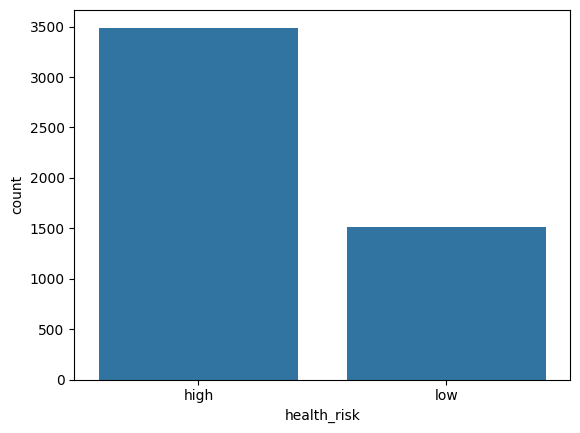

In [13]:
sns.countplot(
    data = df,
    x = "health_risk",
   
)
plt.show()

 Insight ---- This dataset is imbalanced,with significantly more high health risk casses(around 3500) than low health cases(around 1500).This indicates that individuals classified as high health risk as more prevalent in the dataset 

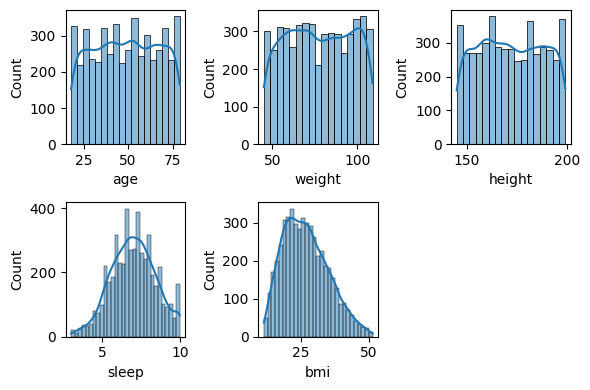

In [14]:
# histplot distribution among numerical columns

num_cols = df.select_dtypes(include = ['int64','float']).columns
plt.figure(figsize = (6,4))

for i,col in enumerate(num_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df[col],kde = True)

plt.tight_layout()
plt.show()
    
    

Insight : Age, weight, and height are relatively uniformly distributed, sleep follows an approximately normal distribution, and BMI is right-skewed with a longer tail toward higher values.

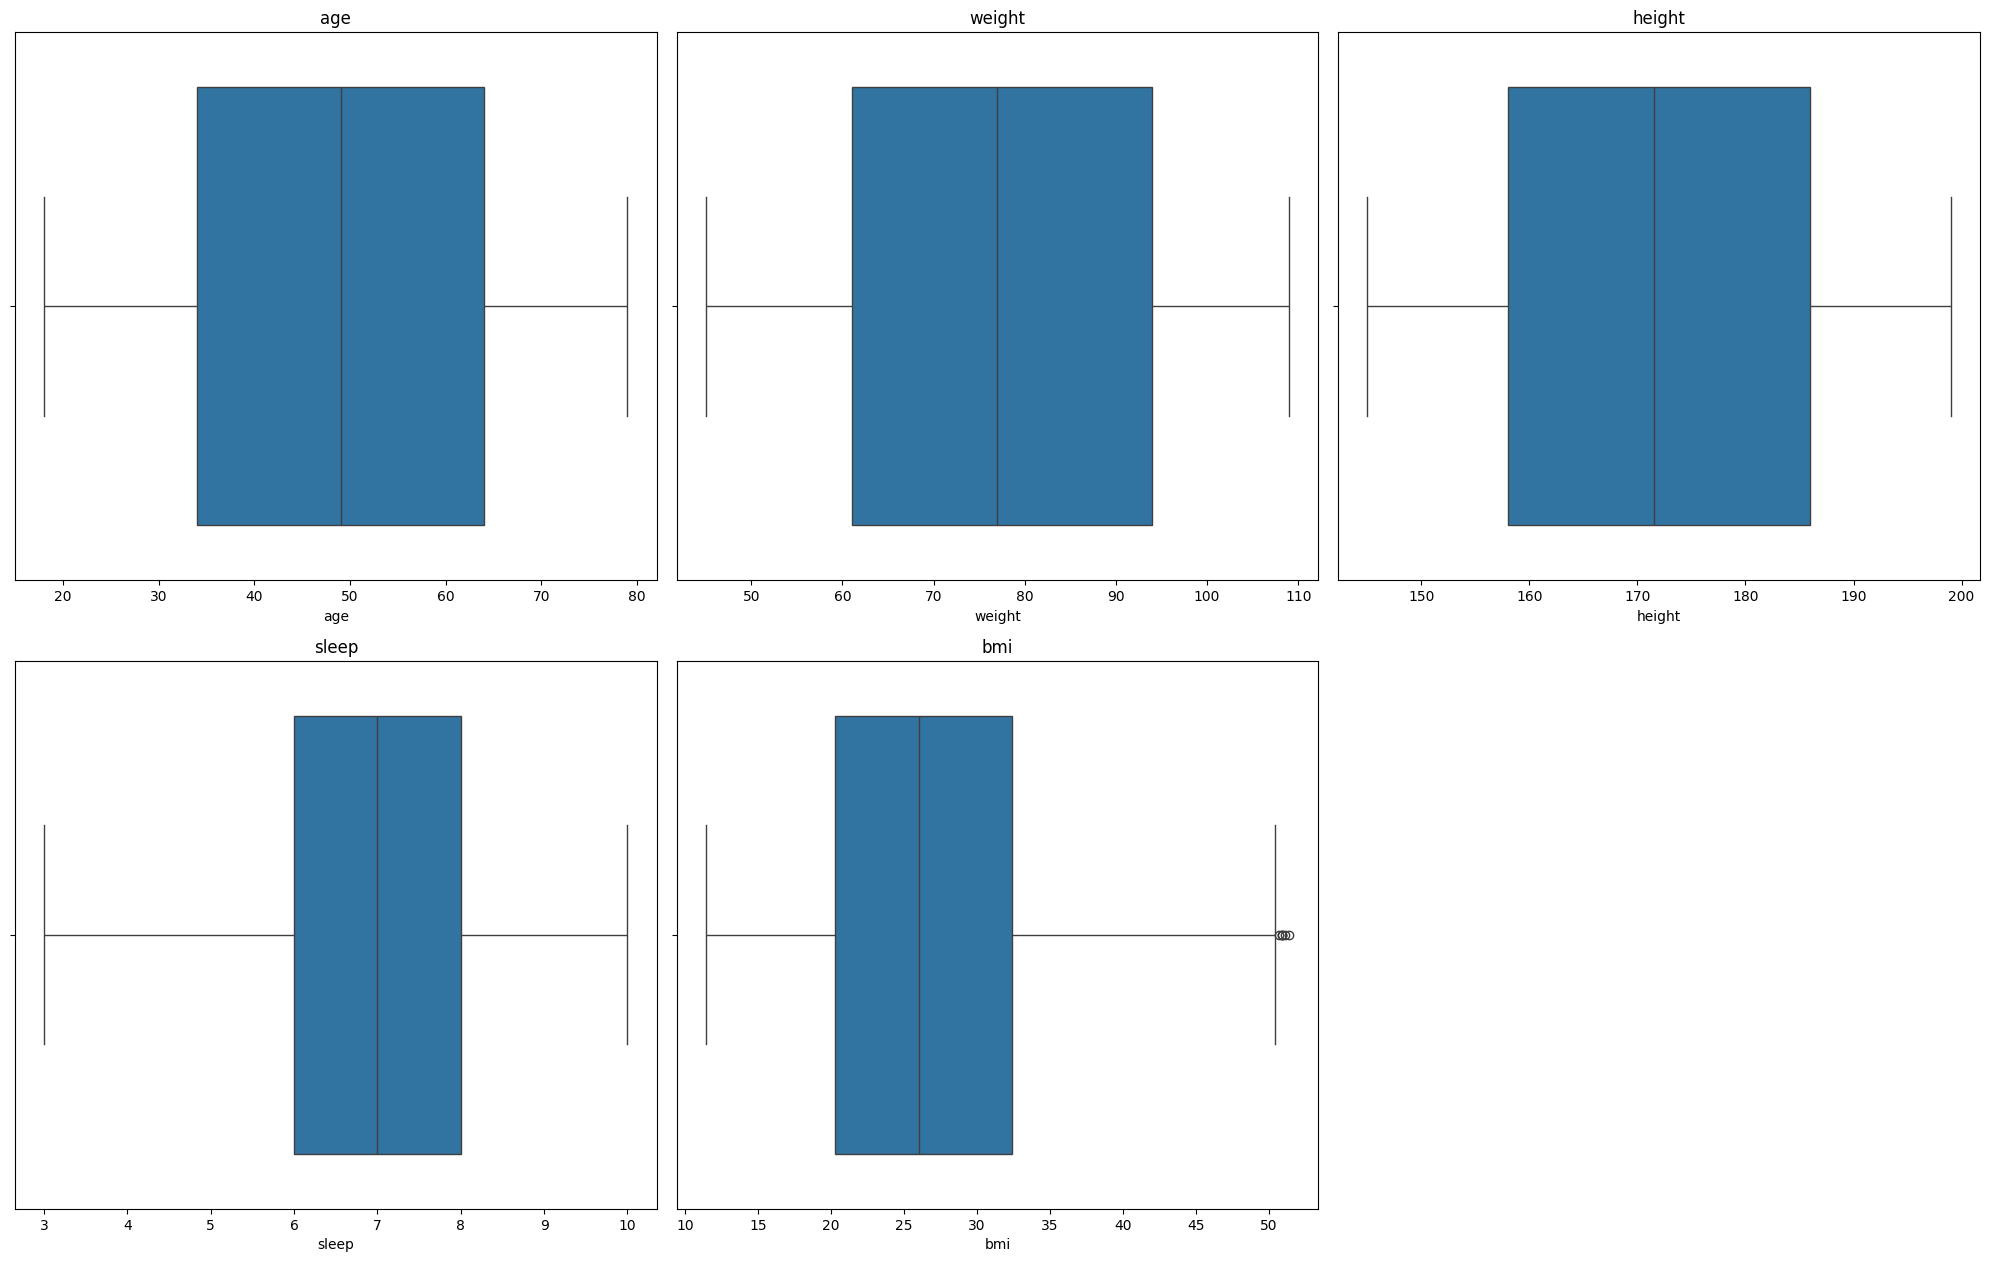

In [15]:
#boxplot distribution among numerical 

num_cols = df.select_dtypes(include="number").columns
plt.figure(figsize=(20, 50))

for i, col in enumerate(num_cols, 1):
    plt.subplot(8, 3, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Insight --- No significant outlier but in bmi have a small upper outlier

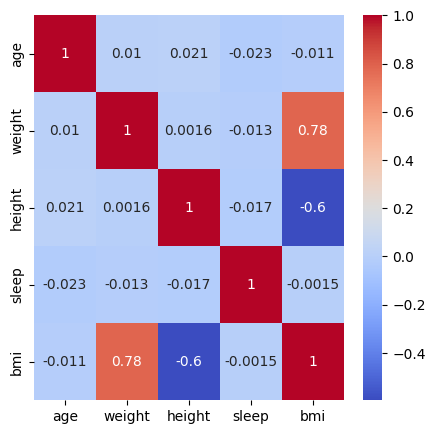

In [16]:
#Heatmap
plt.figure(figsize=(5,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [17]:
# categorical_count

cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    display(
       df[col].value_counts().rename_axis(col).reset_index(name='Count')
    )


,exercise,Count
0,medium,1985
1,low,1272
2,high,1000
3,none,743


,sugar_intake,Count
0,medium,2511
1,low,1484
2,high,1005


,smoking,Count
0,no,4023
1,yes,977


,alcohol,Count
0,no,3741
1,yes,1259


,married,Count
0,yes,3018
1,no,1982


,profession,Count
0,student,644
1,farmer,639
2,driver,631
3,doctor,630
4,artist,626
5,engineer,616
6,teacher,612
7,office_worker,602


,health_risk,Count
0,high,3490
1,low,1510


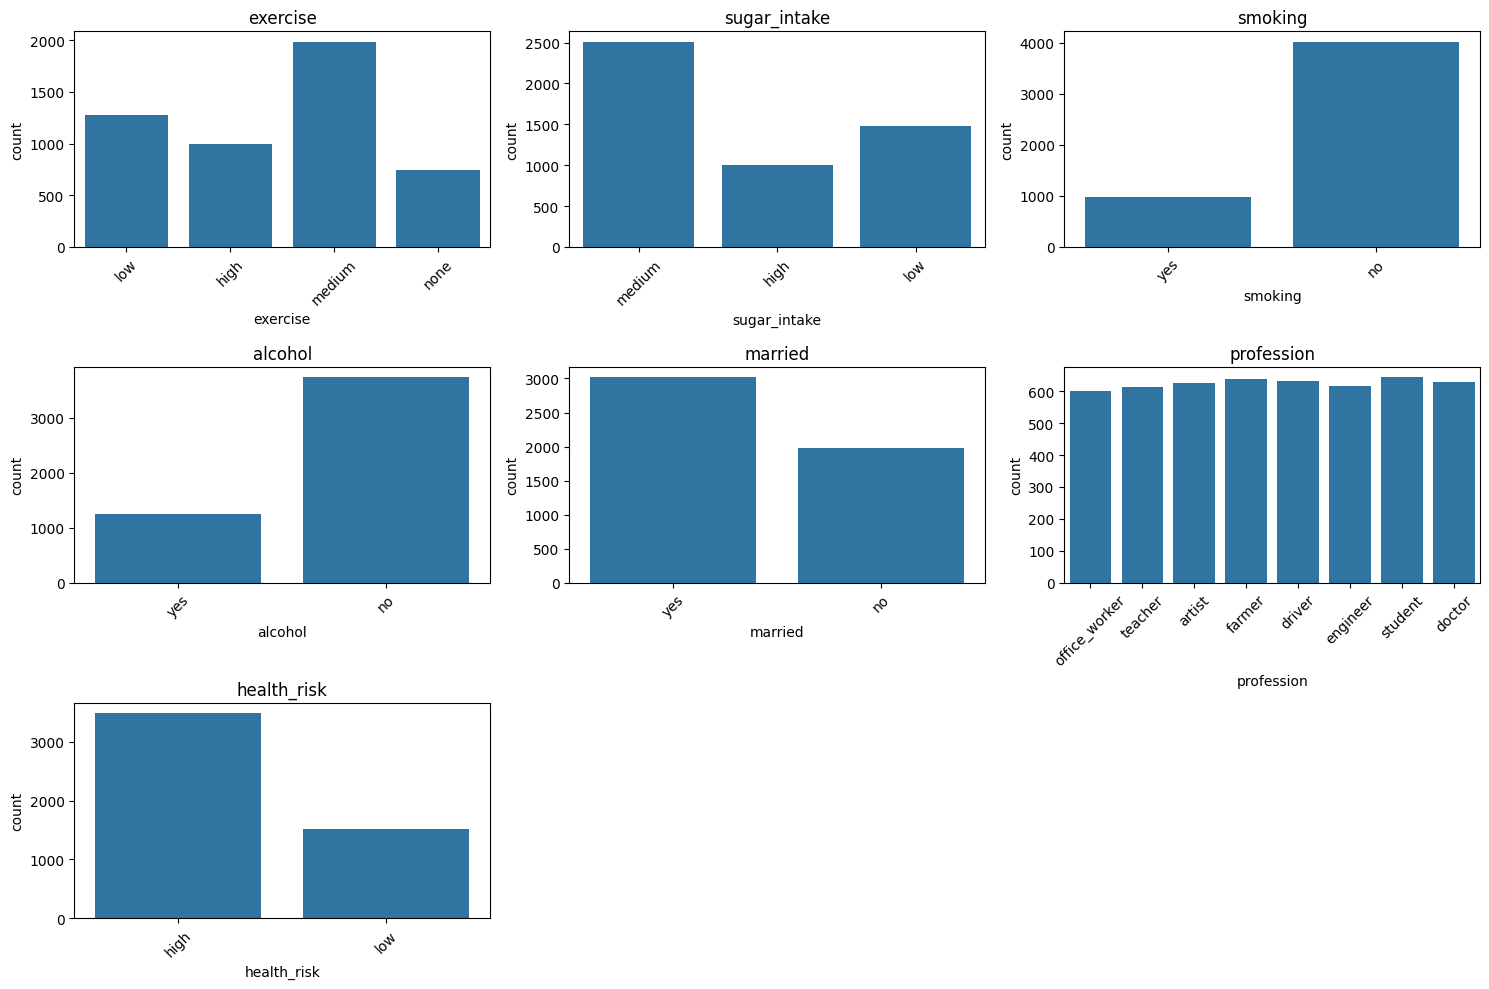

In [18]:
#Countplot distribution among categorical

cat_cols = df.select_dtypes(include=["object", "category"]).columns
plt.figure(figsize=(15,10))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()